In [ ]:
!pip install transformers datasets accelerate scikit-learn matplotlib -q

In [ ]:
#ran into problem with torch version in Collab, so I am installing the specific version that is compatible with the other packages
!pip install torch==2.4.0 torchvision==0.19.0  torchaudio==2.4.0 -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html


In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import torch


In [4]:
# Load dataset
ds = load_dataset("auphong2707/game-reviews-sentiment")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
# Choosing a range of data to lessen trainng time
train_ds = ds["train"].shuffle(seed=42).select(range(20000))
val_ds = ds["validation"].shuffle(seed=42).select(range(2000))
test_ds = ds["test"].shuffle(seed=42).select(range(2000))



In [6]:
#Map labels to ints
label_list = ["negative", "mixed", "positive"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

def encode_labels(batch):
    batch["label"] = [label2id[c] for c in batch["review_category"]]
    return batch

train_ds = train_ds.map(encode_labels, batched=True)
val_ds = val_ds.map(encode_labels, batched=True)
test_ds = test_ds.map(encode_labels, batched=True)



In [7]:
#model and tokenization
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["review_text"], truncation=True, padding="max_length", max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)



In [8]:
#dataset formatting
cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
args = TrainingArguments(
    output_dir="./game-review-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

In [10]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

trainer = Trainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)
trainer.train()
print(trainer.evaluate(test_ds))

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.452939,0.460343,0.821500,0.743043
2,0.339355,0.451976,0.840000,0.766181
3,0.237732,0.519148,0.835000,0.763058


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.237732,0.469668,3,0.833000,0.761547


{'eval_loss': 0.46966779232025146, 'eval_accuracy': 0.833, 'eval_f1_macro': 0.7615472744536259}


In [11]:
save_path = "./game-review-sentiment-model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./game-review-sentiment-model/tokenizer_config.json',
 './game-review-sentiment-model/tokenizer.json')

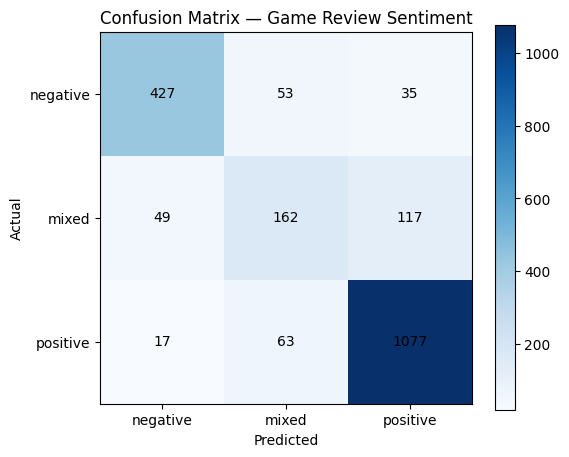

In [19]:
#confusion matrix Generation
preds_output = trainer.predict(test_ds)
preds = np.argmax(preds_output.predictions, axis=1)
labels = preds_output.label_ids
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(3), label_list)
plt.yticks(range(3), label_list)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Game Review Sentiment")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

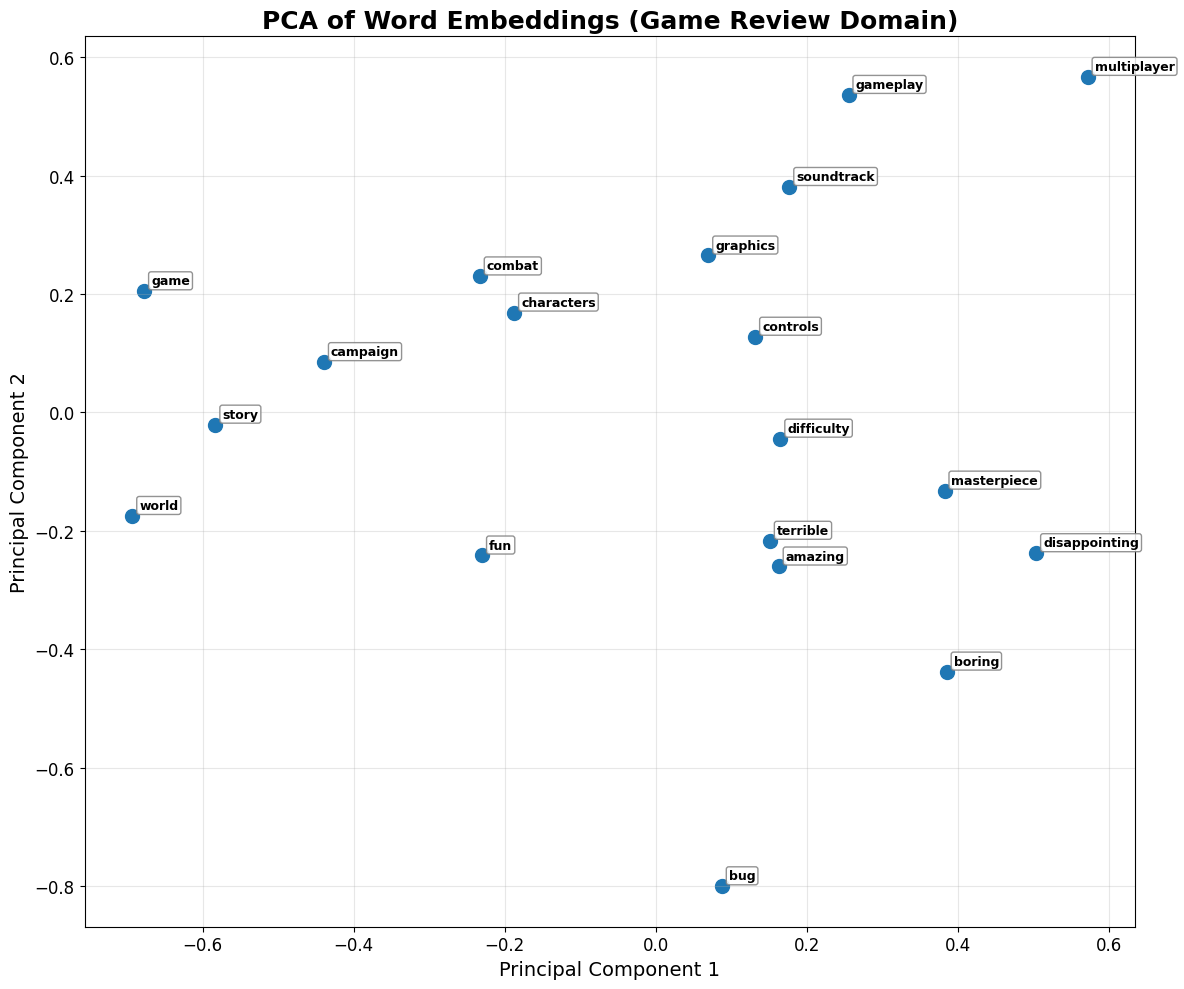

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

words = ["game", "graphics", "story", "gameplay", "bug", "glitch", "fun",
          "boring", "amazing", "terrible", "multiplayer", "campaign",
          "controls", "difficulty", "soundtrack", "characters", "world",
          "combat", "disappointing", "masterpiece"]

embedding_layer = model.distilbert.embeddings.word_embeddings.weight.detach().cpu().numpy()

vectors = []
valid_words = []
for w in words:
    tok_id = tokenizer.convert_tokens_to_ids(w)
    if tok_id != tokenizer.unk_token_id:
        vectors.append(embedding_layer[tok_id])
        valid_words.append(w)

vectors = np.array(vectors)
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)


plt.figure(figsize=(12, 10))
plt.scatter(reduced[:, 0], reduced[:, 1], s=100)

for i, word in enumerate(valid_words):
    plt.annotate(
        word,
        (reduced[i, 0], reduced[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.85,
            boxstyle="round,pad=0.2"
        )
    )

plt.title("PCA of Word Embeddings (Game Review Domain)", fontsize=18, fontweight="bold")
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_word_embeddings.png", dpi=300)
plt.show()